# **LAB ASSIGNMENT 1**

---


##IMPOTING LIBRARIES

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
sns.set(style="whitegrid")

##READING csv

In [117]:
data = pd.read_csv("/student_data.csv")

#**Part 1**
##**Q1**

In [118]:
print(data.head(10))
print(data.shape)
print(data.info())



    Age  Gender        Department  CGPA  Study_Hours  Graduated  \
0  20.0    Male          Business   NaN         12.7          0   
1  19.0    Male              Arts  2.71          6.0          1   
2  19.0    Male          business  3.41         52.0          0   
3  20.0  Female              Arts  2.66          3.7          1   
4  45.0  Female  Computer Science  2.64         10.1          1   
5  50.0    Male       Engineering  2.41          9.2          1   
6  18.0  Female       Mathematics  2.71         12.0          1   
7  22.0    Male          Business  2.90          7.5          0   
8  21.0  Female       Mathematics   NaN         10.3          1   
9  18.0  Female       Engineering  2.22          1.0          0   

   Admission grade  Unemployment rate  Inflation rate   GDP  \
0            127.3               10.8             1.4  1.74   
1            142.5               13.9            -0.3  0.79   
2            124.8               10.8             1.4  1.74   
3         

**Interpretation**



*   The dataset contains X rows and Y columns.
*   Features include student information like Department, Gender, Study Hours, CGPA etc.

*   Checking data types helps identify numerical and categorical variables for preprocessing.








#**Q2**

In [119]:
data.describe()
data.mean(numeric_only=True)
data.median(numeric_only=True)
data.min(numeric_only=True)
data.max(numeric_only=True)
data["CGPA"].max()
data["Study_Hours"].max()

96.6

**Interpretation**


*   CGPA should normally be between 0 and 4.0
*   If CGPA > 4 appears, it is invalid data

* Very high study hours (e.g., 16+ hours daily) may also be unrealistic



##**PART 2**
##**Q3**

In [120]:
missing_columns = data.columns[data.isnull().any()]
print("Columns with missing values:")
print(missing_columns)
print(data.isnull().sum()/len(data) * 100)
columns = data.select_dtypes(include=["int","float"]).columns
for col in columns:
  data[col]=data[col].fillna(data[col].median())
columns = data.select_dtypes(include=["object"]).columns
for col in columns:
  data[col]=data[col].fillna(data[col].mode()[0])



Columns with missing values:
Index(['Age', 'Gender', 'Department', 'CGPA', 'Study_Hours'], dtype='object')
Age                                    3.978300
Gender                                 2.983725
Department                             3.978300
CGPA                                   5.990054
Study_Hours                            4.995479
Graduated                              0.000000
Admission grade                        0.000000
Unemployment rate                      0.000000
Inflation rate                         0.000000
GDP                                    0.000000
Curricular units 1st sem (approved)    0.000000
Curricular units 2nd sem (approved)    0.000000
dtype: float64


##**Q4**

In [121]:
print(data['Department'].unique())
print(data['Gender'].unique())
data['Department']=data['Department'].str.upper()
data['Department']=data['Department'].replace({
    "CS":"COMPUTER SCIENCE",
    "COMP SCIENCE":"COMPUTER SCIENCE",
    'ENGG' : 'ENGINEERING',
    'BUSSINESS' : 'BUSINESS'

})
print(data['Department'].unique())
data['Gender']=data['Gender'].str.upper()
data['Gender'] = data['Gender'].replace({
    'M': "MALE",
    "F":"FEMALE"
})
data['Gender'].unique()
data2 = data



['Business' 'Arts' 'business' 'Computer Science' 'Engineering'
 'Mathematics' 'engineering' 'comp science' 'CS' 'computer science'
 'Bussiness' 'Engg' 'ENGINEERING' 'BUSINESS']
['Male' 'Female' 'female' 'male' 'F' 'MALE' 'FEMALE' 'M']
['BUSINESS' 'ARTS' 'COMPUTER SCIENCE' 'ENGINEERING' 'MATHEMATICS']


##**Q5**

In [122]:
# Detect CGPA outliers
print(data[data["CGPA"] > 4])

# Remove invalid CGPA
data = data[data["CGPA"] <= 4]

# Detect high study hours
print(data[data["Study_Hours"] > 16])

# Cap study hours
data["Study_Hours"] = data["Study_Hours"].clip(upper=16)

       Age  Gender   Department  CGPA  Study_Hours  Graduated  \
38    39.0  FEMALE  MATHEMATICS  4.10         14.5          1   
74    18.0    MALE         ARTS  5.06          9.4          1   
99    19.0  FEMALE         ARTS  4.82         13.3          0   
128   18.0  FEMALE         ARTS  4.98          5.5          1   
176   27.0  FEMALE     BUSINESS  5.10         12.3          1   
...    ...     ...          ...   ...          ...        ...   
4163  19.0  FEMALE     BUSINESS  4.26         11.8          1   
4179  18.0  FEMALE     BUSINESS  4.60         10.9          1   
4221  18.0  FEMALE     BUSINESS  4.74          6.4          1   
4337  24.0  FEMALE         ARTS  4.25         11.3          1   
4391  32.0  FEMALE  ENGINEERING  4.77         11.3          0   

      Admission grade  Unemployment rate  Inflation rate   GDP  \
38              113.9                7.6             2.6  0.32   
74              132.9               10.8             1.4  1.74   
99              111.5

/tmp/ipykernel_1514/3248778824.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Study_Hours"] = data["Study_Hours"].clip(upper=16)


**Justification**


*   CGPA cannot exceed 4.0 in most grading systems
*   Study hours beyond 16 per day are unrealistic
*   Instead of removing data, capping preserves dataset size









##**PART3**
##**Q6**

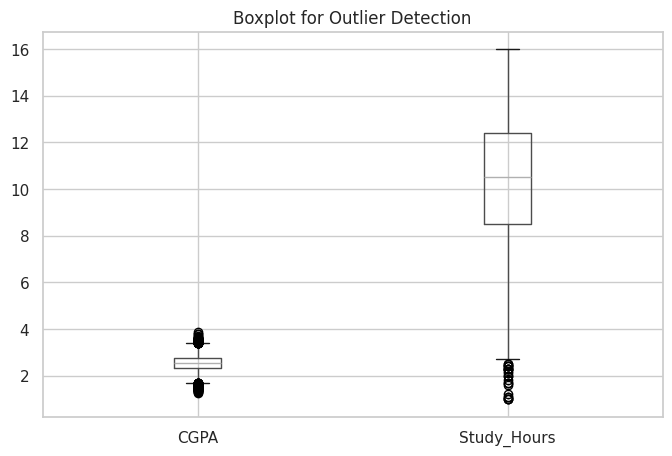

Outliers using IQR:
       Age  Gender        Department  CGPA  Study_Hours  Graduated  \
9     18.0  FEMALE       ENGINEERING  2.22          1.0          0   
355   18.0  FEMALE       ENGINEERING  3.19          2.4          1   
427   20.0  FEMALE          BUSINESS  1.98          2.5          0   
525   31.0    MALE              ARTS  2.21          1.7          0   
1035  18.0  FEMALE  COMPUTER SCIENCE  2.53          2.3          0   
1196  20.0  FEMALE          BUSINESS  1.86          1.1          0   
1410  58.0  FEMALE       MATHEMATICS  3.22          1.6          0   
1515  21.0  FEMALE          BUSINESS  2.53          2.1          1   
1594  19.0    MALE          BUSINESS  2.13          1.7          0   
1866  26.0    MALE       MATHEMATICS  2.25          2.3          0   
2111  20.0  FEMALE              ARTS  3.08          2.2          1   
2238  24.0    MALE  COMPUTER SCIENCE  2.15          1.1          0   
2333  20.0    MALE          BUSINESS  1.37          2.0          0   


In [123]:

plt.figure(figsize=(8,5))
data.boxplot(column=["CGPA","Study_Hours"])
plt.title("Boxplot for Outlier Detection")
plt.show()

Q1 = data["Study_Hours"].quantile(0.25)
Q3 = data["Study_Hours"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = data[(data["Study_Hours"] < lower) | (data["Study_Hours"] > upper)]

print("Outliers using IQR:")
print(outliers_iqr)

z_scores = np.abs(stats.zscore(data["Study_Hours"]))

outliers_z = data[z_scores > 3]

print("Outliers using Z-score:")
print(outliers_z)
print("Shape before removing outliers:", data.shape)
data_clean = data[(data["Study_Hours"] >= lower) & (data["Study_Hours"] <= upper)]
print("Shape after removing outliers:", data_clean.shape)


#**PART 4**
##**Q7**

In [124]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

data["Graduated"] = le.fit_transform(data["Graduated"])
data = pd.get_dummies(data, columns=["Department","Gender"])
data.head(5)

/tmp/ipykernel_1514/407516883.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Graduated"] = le.fit_transform(data["Graduated"])


,Age,CGPA,Study_Hours,Graduated,Admission grade,Unemployment rate,Inflation rate,GDP,Curricular units 1st sem (approved),Curricular units 2nd sem (approved),Department_ARTS,Department_BUSINESS,Department_COMPUTER SCIENCE,Department_ENGINEERING,Department_MATHEMATICS,Gender_FEMALE,Gender_MALE
0,20.0,2.53,12.7,0,127.3,10.8,1.4,1.74,0,0,False,True,False,False,False,False,True
1,19.0,2.71,6.0,1,142.5,13.9,-0.3,0.79,6,6,True,False,False,False,False,False,True
2,19.0,3.41,16.0,0,124.8,10.8,1.4,1.74,0,0,False,True,False,False,False,False,True
3,20.0,2.66,3.7,1,119.6,9.4,-0.8,-3.12,6,5,True,False,False,False,False,True,False
4,45.0,2.64,10.1,1,141.5,13.9,-0.3,0.79,5,6,False,False,True,False,False,True,False


##**Q8**

In [125]:
features = ["Age", "CGPA", "Study_Hours"]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_standard = data.copy()
data_standard[features] = scaler.fit_transform(data[features])
print("StandardScaler result:")
print(data_standard[features].head())

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data_minmax = data.copy()
data_minmax[features] = scaler.fit_transform(data[features])
print("MinMaxScaler result:")
print(data_minmax[features].head())

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
data_robust = scaler.fit_transform(data[features])

StandardScaler result:
        Age      CGPA  Study_Hours
0 -0.417124 -0.006694     0.773096
1 -0.552091  0.488522    -1.510770
2 -0.552091  2.414360     1.897986
3 -0.417124  0.350962    -2.294784
4  2.957062  0.295938    -0.113180
MinMaxScaler result:
        Age      CGPA  Study_Hours
0  0.056604  0.486590     0.780000
1  0.037736  0.555556     0.333333
2  0.037736  0.823755     1.000000
3  0.056604  0.536398     0.180000
4  0.528302  0.528736     0.606667


##**Q9**

Skewness of features:
Age                                    2.142667
CGPA                                   0.041285
Study_Hours                           -0.134106
Graduated                              0.011064
Admission grade                        0.515793
Unemployment rate                      0.211067
Inflation rate                         0.254739
GDP                                   -0.399410
Curricular units 1st sem (approved)    0.774701
Curricular units 2nd sem (approved)    0.304740
Department_ARTS                        1.996989
Department_BUSINESS                    0.960299
Department_COMPUTER SCIENCE            1.242745
Department_ENGINEERING                 1.613025
Department_MATHEMATICS                 1.991798
Gender_FEMALE                         -0.666666
Gender_MALE                            0.666666
dtype: float64


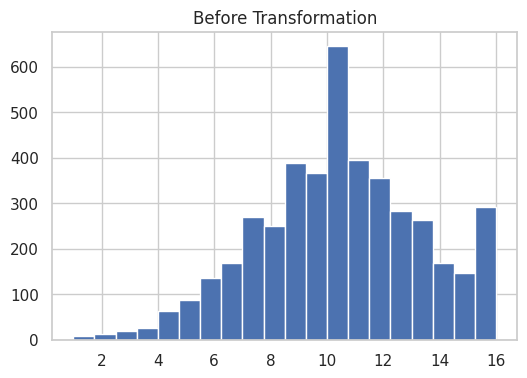

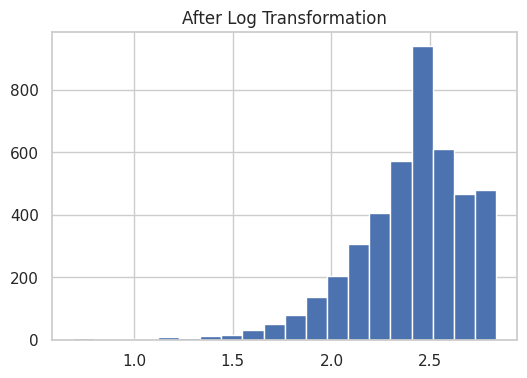

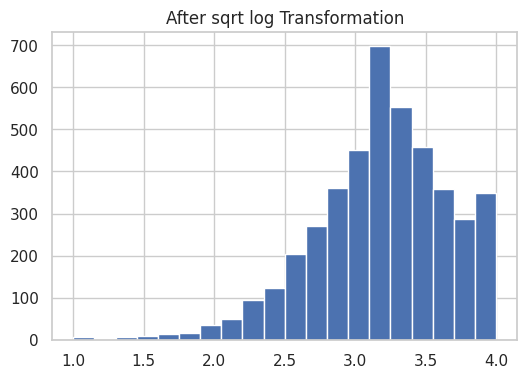

Original skew: -0.1341060369257753
Log skew: -1.1899497301472495
Sqrt skew: -0.6519069541752511


In [126]:
skew_values = data.skew(numeric_only=True)
print("Skewness of features:")
print(skew_values)
data["Study_Hours_log"] = np.log1p(data["Study_Hours"])
data["Study_Hours_sqrt"] = np.sqrt(data["Study_Hours"])
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(data["Study_Hours"], bins=20)
plt.title("Before Transformation")
plt.show()
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(data["Study_Hours_log"], bins=20)
plt.title("After Log Transformation")
plt.show()

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(data["Study_Hours_sqrt"], bins=20)
plt.title("After sqrt log Transformation")
plt.show()

print("Original skew:", data["Study_Hours"].skew())
print("Log skew:", data["Study_Hours_log"].skew())
print("Sqrt skew:", data["Study_Hours_sqrt"].skew())

##**Part 6**
##**Visualization**

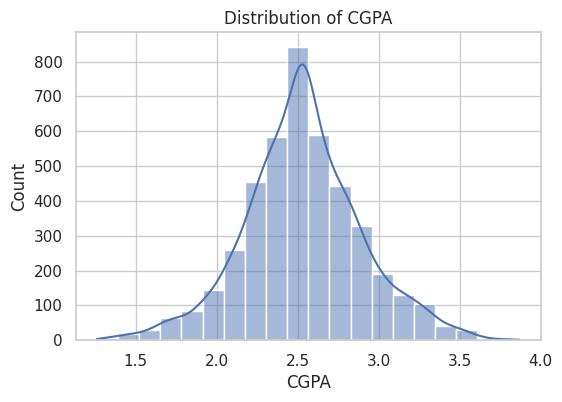

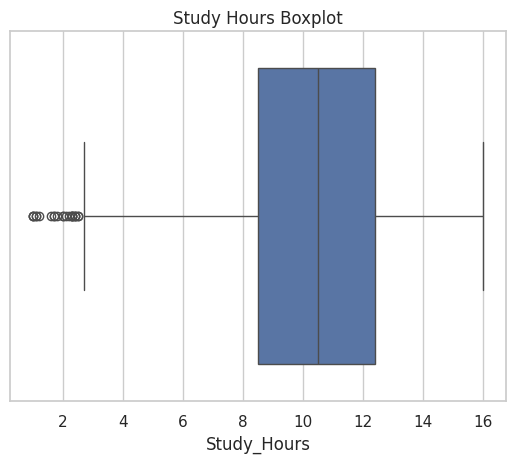

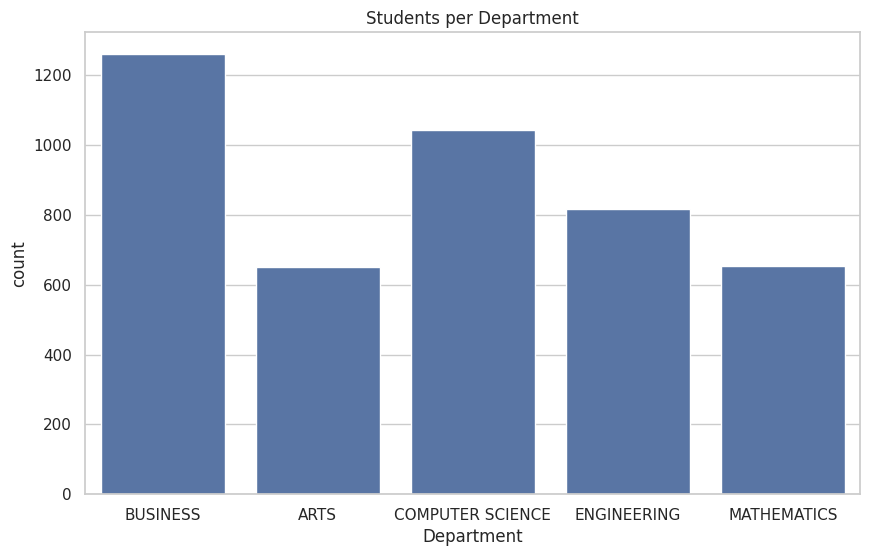

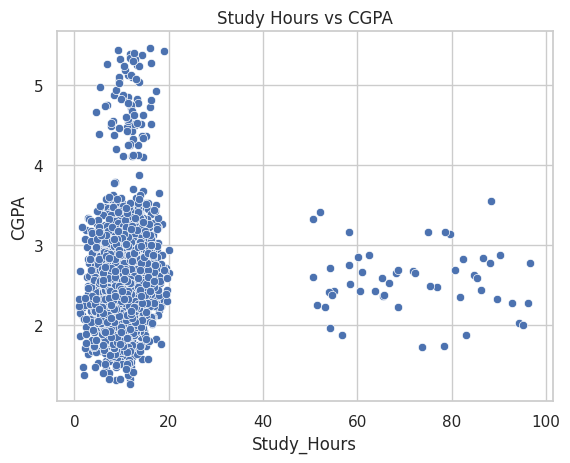

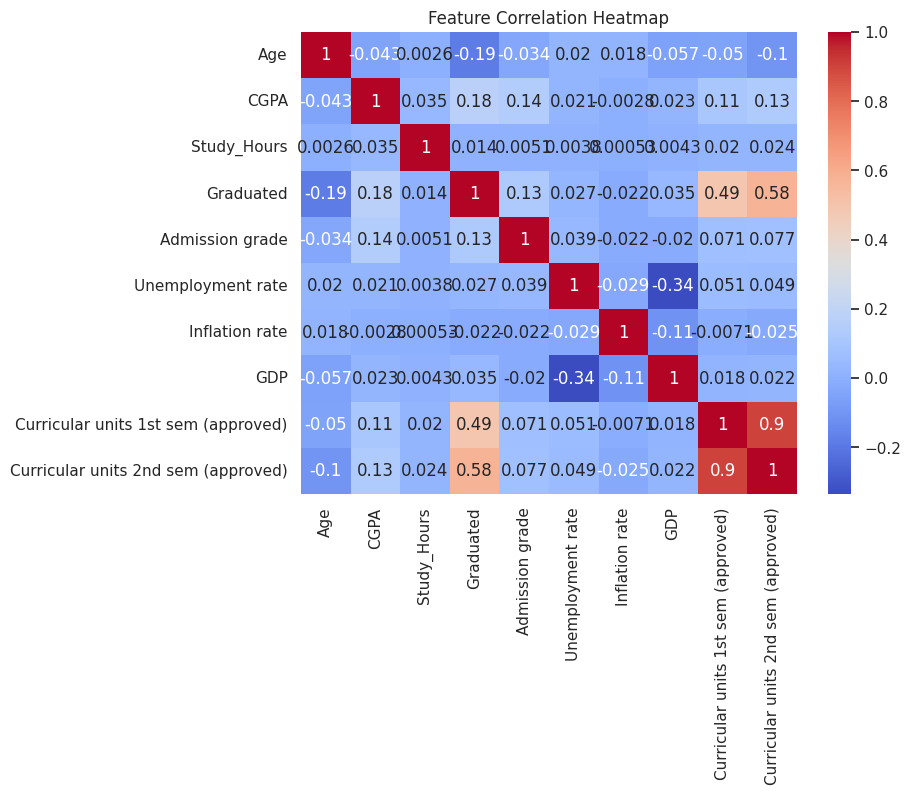

In [127]:
plt.figure(figsize=(6,4))
sns.histplot(data["CGPA"], bins=20, kde=True)
plt.title("Distribution of CGPA")
plt.show()
sns.boxplot(x=data["Study_Hours"])
plt.title("Study Hours Boxplot")
plt.show()
plt.figure(figsize=(10,6))
sns.countplot(x="Department", data=data2)
plt.title("Students per Department")
plt.show()

sns.scatterplot(x="Study_Hours", y="CGPA", data=pd.read_csv("/student_data.csv"))
plt.title("Study Hours vs CGPA")
plt.show()
plt.figure(figsize=(8,6))
sns.heatmap(data2.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()